# Bivariate copula examples

Bivariate fitting, dynamic parameters, OU interpretation, sampling, and prediction.

In [1]:
import time
from pathlib import Path

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from pyscarcopula._utils import pobs
from pyscarcopula import (
    GumbelCopula, FrankCopula, JoeCopula, ClaytonCopula,
    GaussianCopula, StudentCopula, CVineCopula, RVineCopula,
    PredictConfig,
)
from pyscarcopula.api import fit, sample, predict, smoothed_params
from pyscarcopula.stattests import gof_test

DATA_DIR = Path('data')
if not DATA_DIR.exists():
    DATA_DIR = Path('..') / 'data'


## 1. Read dataset and transform to log-returns

In [2]:
crypto_prices = pd.read_csv(DATA_DIR / 'crypto_prices.csv', index_col=0, sep=';')

tickers = ['BTC-USD', 'ETH-USD']
returns = np.log(crypto_prices[tickers] / crypto_prices[tickers].shift(1))[1:].values
u = pobs(returns)

print(f'T = {len(u)}, d = {u.shape[1]}')

T = 1460, d = 2


## 2. Fit bivariate copula and GoF test

Three methods: MLE (constant parameter), SCAR-TM (stochastic with transfer matrix), GAS (score-driven).

In [3]:
copula = GumbelCopula(rotate=180)

result_mle = fit(copula, u, method='mle')
result_tm  = fit(copula, u, method='scar-tm-ou')
result_gas = fit(copula, u, method='gas')

for name, res in [('MLE', result_mle), ('GAS', result_gas), ('SCAR-TM', result_tm)]:
    gof = gof_test(copula, u, fit_result=res, to_pobs=False)
    print(f'{name:8s}  logL = {res.log_likelihood:8.2f}   GoF p = {gof.pvalue:.4f}')

MLE       logL =   955.63   GoF p = 0.0105
GAS       logL =  1031.42   GoF p = 0.5187
SCAR-TM   logL =  1042.47   GoF p = 0.6544


## 3. Time-varying copula parameter

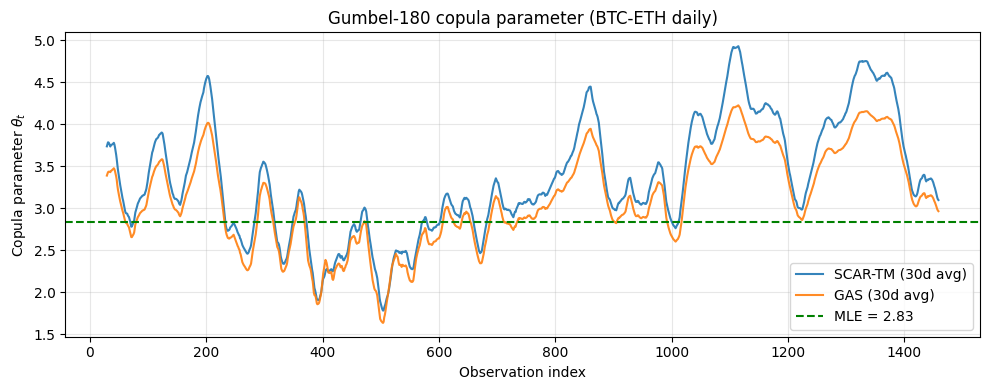

In [4]:
from matplotlib import pyplot as plt

r_mle = smoothed_params(copula, u, result_mle)
r_tm  = smoothed_params(copula, u, result_tm)
r_gas = smoothed_params(copula, u, result_gas)

fig, ax = plt.subplots(figsize=(10, 4))

w = 30
ax.plot(pd.Series(r_tm).rolling(w).mean(), label='SCAR-TM (30d avg)', alpha=0.9)
ax.plot(pd.Series(r_gas).rolling(w).mean(), label='GAS (30d avg)', alpha=0.9)
ax.axhline(r_mle[0], color='green', linestyle='--', label=f'MLE = {r_mle[0]:.2f}')

ax.set_ylabel(r'Copula parameter $\theta_t$')
ax.set_xlabel('Observation index')
ax.set_title('Gumbel-180 copula parameter (BTC-ETH daily)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. OU process parameters

In [5]:
p = result_tm.params
sigma = p.nu / np.sqrt(2 * p.theta)
tau = len(u) / p.theta

print(f'theta = {p.theta:.2f} (mean reversion speed)')
print(f'mu    = {p.mu:.2f} (long-run mean in latent space)')
print(f'nu    = {p.nu:.2f} (volatility)')
print(f'sigma = {sigma:.2f} (stationary std dev)')
print(f'tau   = {tau:.0f} (mean reversion time in obs steps)')

theta = 49.98 (mean reversion speed)
mu    = 2.43 (long-run mean in latent space)
nu    = 10.66 (volatility)
sigma = 1.07 (stationary std dev)
tau   = 29 (mean reversion time in obs steps)


## 5. Sample and predict

Two functions with different purposes:

- **`sample`** reproduces the fitted model (for validation). `fit(copula, sample(...))` should recover similar parameters.
- **`predict`** generates next-step forecasts conditional on observed data (for risk metrics).

In [6]:
# Model validation: sample -> refit -> GoF
v = sample(copula, u, result_tm, n=len(u))
v_pobs = pobs(v)
result_refit = fit(copula, v_pobs, method='scar-tm-ou')
gof_v = gof_test(copula, v_pobs, fit_result=result_refit, to_pobs=False)

p1 = result_tm.params
p2 = result_refit.params
print(f'Original: theta={p1.theta:.2f}, mu={p1.mu:.2f}, nu={p1.nu:.2f}')
print(f'Refit:    theta={p2.theta:.2f}, mu={p2.mu:.2f}, nu={p2.nu:.2f}')
print(f'GoF on sample: p={gof_v.pvalue:.4f}')

Original: theta=49.98, mu=2.43, nu=10.66
Refit:    theta=119.48, mu=2.87, nu=14.90
GoF on sample: p=0.9622


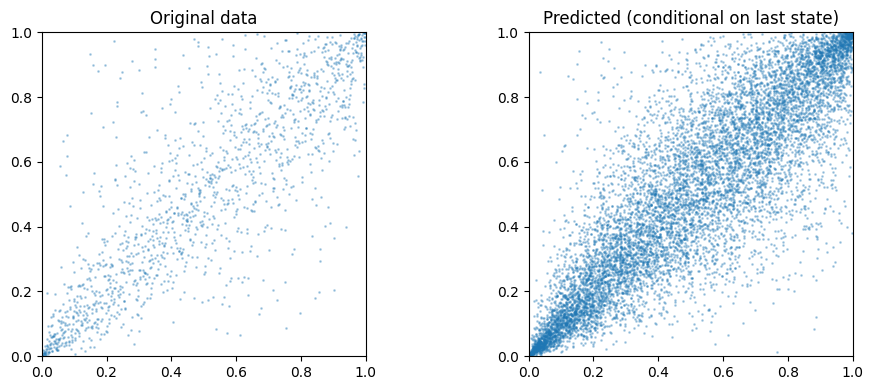

In [7]:
# Prediction: conditional on current market state
u_pred = predict(copula, u, result_tm, n=10000)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(u[:, 0], u[:, 1], s=1, alpha=0.3)
axes[0].set_title('Original data')
axes[1].scatter(u_pred[:, 0], u_pred[:, 1], s=1, alpha=0.3)
axes[1].set_title('Predicted (conditional on last state)')
for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Bivariate predictive horizons

The top-level `api.predict` accepts `given` for vine copulas only.
For bivariate copulas, `given` is ignored; use `horizon='current'` or `'next'` to choose the predictive state for dynamic models.

In [8]:
u_pred_current = predict(copula, u, result_tm, n=5000, horizon='current')
u_pred_next = predict(copula, u, result_tm, n=5000, horizon='next')

print('Predictive sample shapes:', u_pred_current.shape, u_pred_next.shape)
print('Mean U1, current horizon:', u_pred_current[:, 0].mean())
print('Mean U1, next horizon:   ', u_pred_next[:, 0].mean())
print('Mean U2, current horizon:', u_pred_current[:, 1].mean())
print('Mean U2, next horizon:   ', u_pred_next[:, 1].mean())

Predictive sample shapes: (5000, 2) (5000, 2)
Mean U1, current horizon: 0.4916270941813489
Mean U1, next horizon:    0.4976327507249218
Mean U2, current horizon: 0.49605969611282874
Mean U2, next horizon:    0.49612448838944867
